# Exploratory data analysis — Ames Housing

This notebook explores the raw training data (1460 houses, 79 predictive
features) before any of the cleaning or modeling logic runs. It calls into
`src/data.py` for loading and the target log-transform so this exploration
never drifts out of sync with what the training pipeline actually does, but
it is not required for training — `notebooks/01_baseline_training.ipynb` and
`python -m src.train` are self-contained.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from omegaconf import OmegaConf

from src.data import load_raw_data, apply_log_target

plt.style.use("default")

cfg = OmegaConf.load("../configs/train.yaml")
df = load_raw_data(f"../{cfg.data.train_path}", cfg.data.id_column)
df.shape

(1460, 80)

## Missingness and types

A handful of columns are missing almost everywhere they exist at all
(`PoolQC`, `MiscFeature`, `Alley`, `Fence`) — for most houses that simply
means "no pool" / "no alley access" rather than a data-quality problem,
which is why the cleaning step in `src/data.py` fills those with the string
`"None"` instead of imputing a value.

In [2]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageType        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
dtype: int64

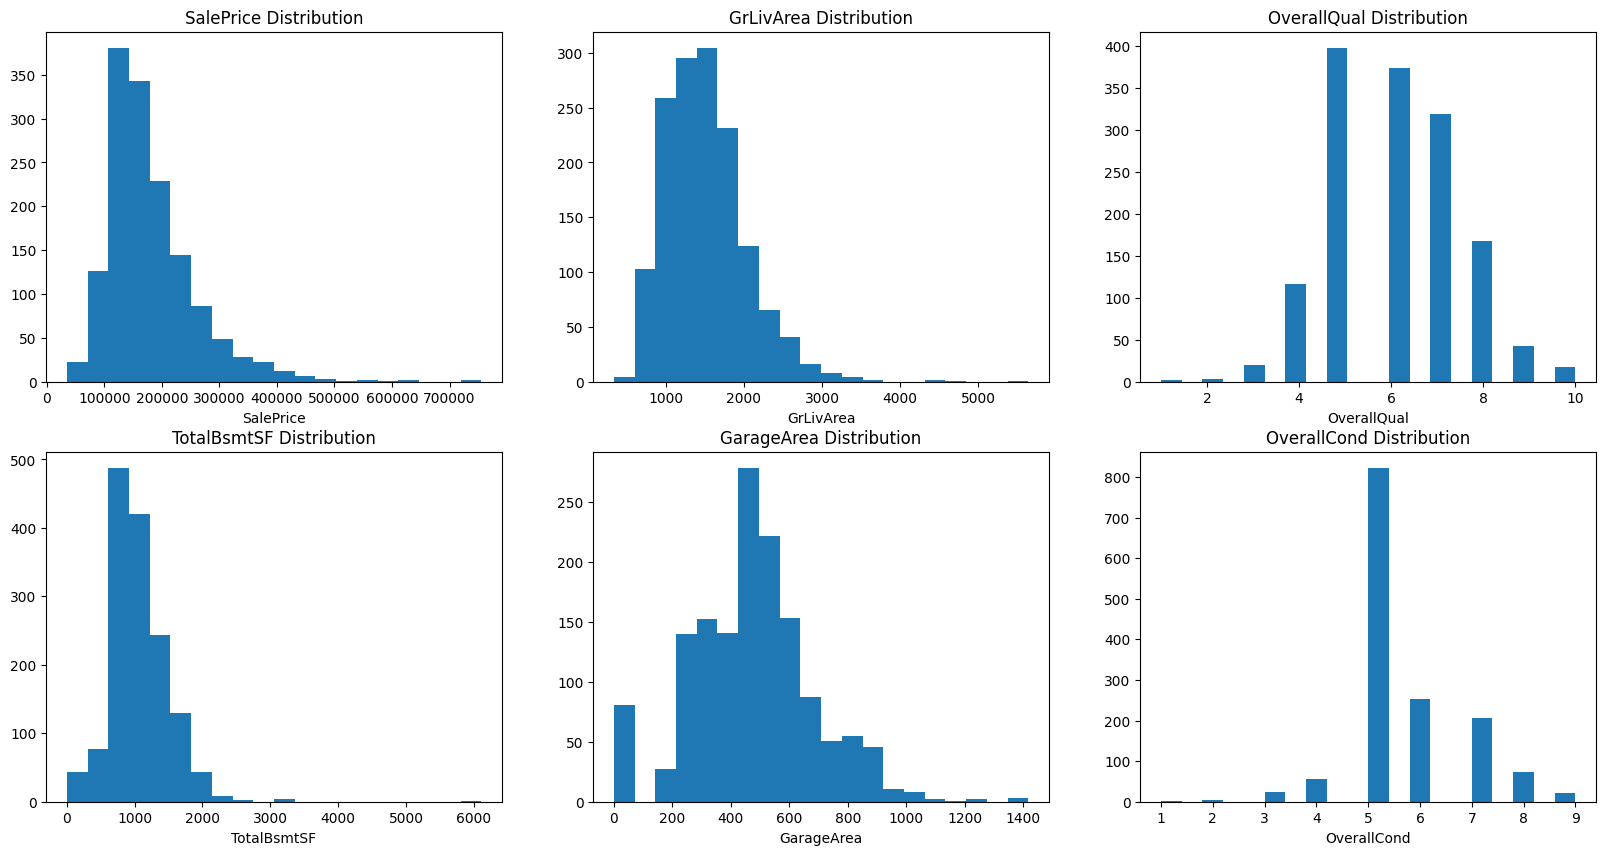

In [3]:
def histogram_multiple(df, cols, fig_size_x, fig_size_y, n_rows, n_cols):
    plt.figure(figsize=(fig_size_x, fig_size_y))
    for i, col in enumerate(cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        plt.hist(x=df[col], bins=20)
        plt.xlabel(col)
        plt.title(col + " Distribution")
    plt.show()


def box_plot_multiple(df, cols, fig_size_x, fig_size_y, n_rows, n_cols):
    plt.figure(figsize=(fig_size_x, fig_size_y))
    for i, col in enumerate(cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        plt.boxplot(x=df[col])
        plt.xlabel(col)
        plt.title(col + " Distribution")
    plt.show()


hist_plot_columns = ["SalePrice", "GrLivArea", "OverallQual", "TotalBsmtSF", "GarageArea", "OverallCond"]
histogram_multiple(df, hist_plot_columns, fig_size_x=20, fig_size_y=10, n_cols=3, n_rows=2)

`SalePrice` is heavily right-skewed — a long tail of expensive houses pulls
the mean above the median. Linear models assume roughly normal, homoscedastic
residuals, so a raw-dollar target tends to make them over-focus on
high-price outliers. `GrLivArea` and `TotalBsmtSF` show the same skew, which
is expected since larger/pricier houses are rarer by construction.

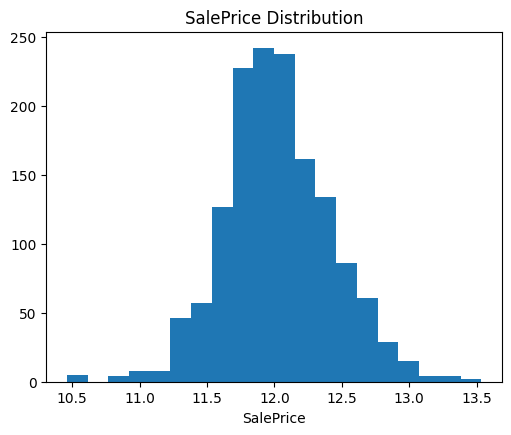

In [4]:
df_log = apply_log_target(df, cfg.data.target_column)
histogram_multiple(df_log, ["SalePrice"], fig_size_x=20, fig_size_y=10, n_cols=3, n_rows=2)

`log1p(SalePrice)` is close to symmetric. This is the target the models are
actually trained on (`src/data.py::apply_log_target`); every RMSE reported
later is converted back to dollars with `expm1` before being compared, so
the reported errors stay interpretable as real prices, not log-price
units.

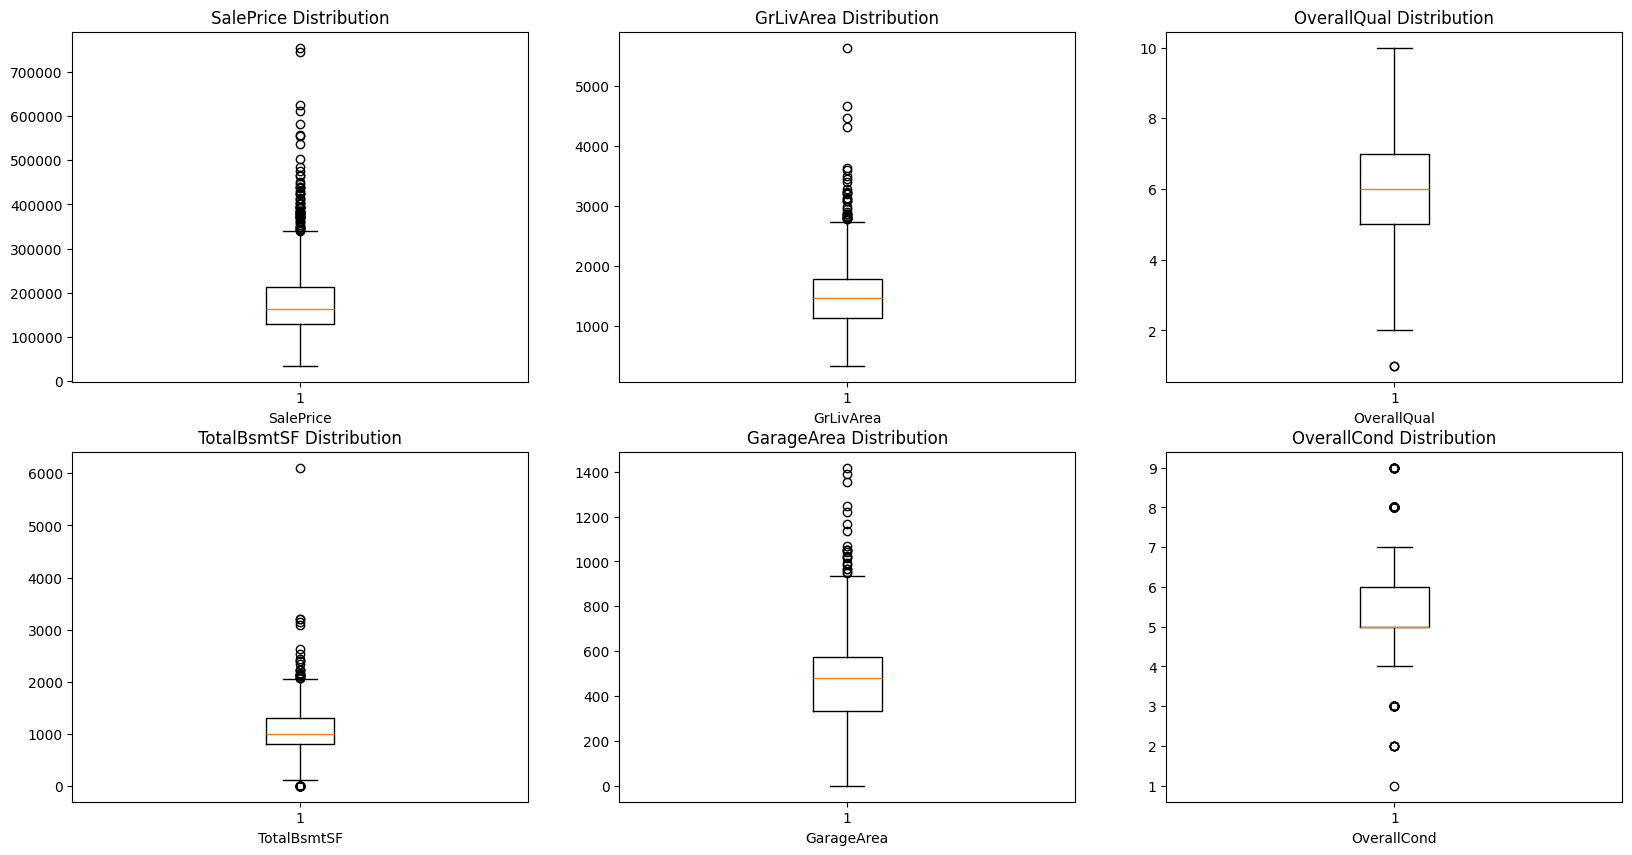

In [5]:
box_plot_multiple(df, hist_plot_columns, fig_size_x=20, fig_size_y=10, n_cols=3, n_rows=2)

Boxplots make the outliers concrete: a small number of houses with unusually
large `GrLivArea` or `TotalBsmtSF` relative to their `OverallQual` sit well
outside the whiskers. They are kept in the training set here (no outlier
removal step exists in this pipeline) — worth flagging as a follow-up, since
a few of Ames' well-known large-area/low-price outliers are known to hurt
linear models specifically.

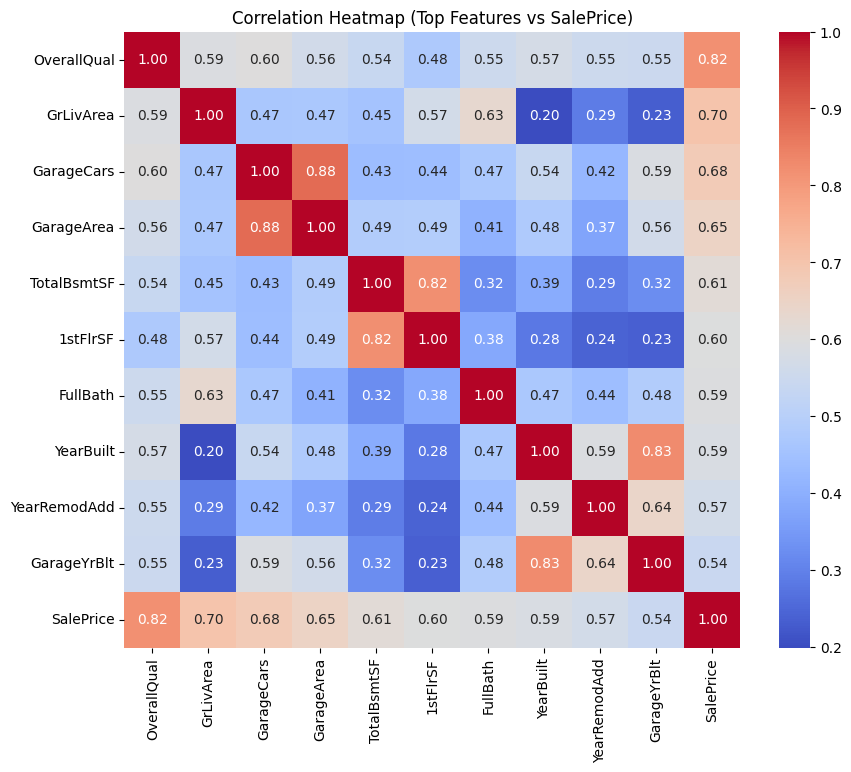

In [6]:
df_numeric = df_log.select_dtypes(include=["int64", "float64"])
corr = df_numeric.corr()["SalePrice"].drop("SalePrice")
top_10 = corr.abs().sort_values(ascending=False).head(10)
corr_matrix = df_numeric[top_10.index.tolist() + ["SalePrice"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Top Features vs SalePrice)")
plt.show()

`OverallQual`, `GrLivArea`, and the garage/basement size features dominate
the correlation with price, which lines up with the RandomForest feature
importances computed later in `01_baseline_training.ipynb` — the two
methods agree on what matters even though they measure "importance"
completely differently (linear correlation vs. split-based impurity
reduction).